# Week 7 live coding: clustering

A 45-minute tutorial to type through together. It covers the three clustering methods from
this week's lecture, k-means, DBSCAN, and Gaussian mixture models, and the questions that
matter more than the algorithms: how many clusters, how stable are they, and what do they
mean.

We work with **national carbon emissions and wealth** from Our World in Data, one row per
country for 2022. There are no labels. The question is whether countries fall into natural
groups by how much they emit, how rich they are, and where their energy comes from.
Assignment 7 applies the same methods to gridded climate normals to find climate zones, so
everything here transfers and nothing here is the answer to the assignment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("pandas ", pd.__version__)
print("sklearn", sklearn.__version__)

pandas  2.3.3
sklearn 1.7.2


## 1. Load the data and choose features

The Our World in Data CO$_2$ dataset is one CSV covering every country and year. We keep the
2022 rows for actual countries (the file also has aggregates such as "Asia" and "World",
which have no ISO code or an `OWID_` code) and build four features:

| Feature | Meaning |
| --- | --- |
| `co2_pc` | territorial CO$_2$ emissions per person, tonnes per year |
| `gdp_pc` | GDP per person, international dollars |
| `energy_pc` | primary energy use per person, kWh per year |
| `coal_share` | fraction of the country's CO$_2$ that comes from coal |

In [2]:
url = "https://github.com/owid/co2-data/raw/master/owid-co2-data.csv"
raw = pd.read_csv(url)
raw["iso_code"] = raw["iso_code"].fillna("")

c = raw[(raw["year"] == 2022) & (raw["iso_code"] != "") & ~raw["iso_code"].str.startswith("OWID")].copy()
c["gdp_pc"] = c["gdp"] / c["population"]
c["coal_share"] = c["coal_co2"] / c["co2"]
c = c.rename(columns={"co2_per_capita": "co2_pc", "energy_per_capita": "energy_pc"})

cols = ["co2_pc", "gdp_pc", "energy_pc", "coal_share"]
c = c.dropna(subset=cols).set_index("country")
print(len(c), "countries with all four features")
c[cols].describe().round(2)

129 countries with all four features


,co2_pc,gdp_pc,energy_pc,coal_share
count,129.00,129.00,129.00,129.00
mean,5.00,22418.99,28614.97,0.22
std,5.44,21062.71,33892.35,0.23
min,0.06,688.91,307.10,0.00
25%,1.40,7349.57,6909.17,0.03
50%,3.53,15810.63,18080.92,0.13
75%,6.78,32802.73,33835.21,0.38
max,37.89,131990.53,195336.34,0.91


Two things to notice in that summary. The per-capita columns span two to three orders of
magnitude, so we take logarithms: a doubling of income should count the same whether it
happens at 2,000 or 20,000 dollars. And the columns have wildly different units. Every
clustering method here works on **distances**, and a distance in raw units would be dominated
by whichever column has the biggest numbers. So we standardize.

In [3]:
from sklearn.preprocessing import StandardScaler

feat = pd.DataFrame({
    "log_co2_pc":    np.log10(c["co2_pc"]),
    "log_gdp_pc":    np.log10(c["gdp_pc"]),
    "log_energy_pc": np.log10(c["energy_pc"]),
    "coal_share":    c["coal_share"],
}, index=c.index)

scaler = StandardScaler().fit(feat)
X = scaler.transform(feat)
print("feature matrix:", X.shape)

feature matrix: (129, 4)


Look at the data before clustering it. Emissions against income is the natural view.

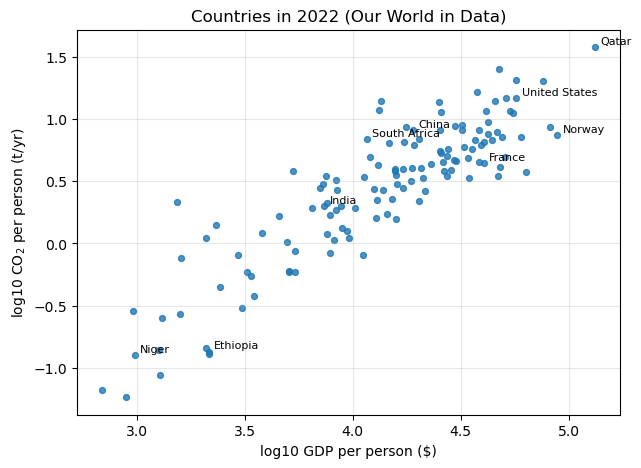

In [4]:
def scatter(ax, color=None, cmap="tab10", title=""):
    kw = dict(c=color, cmap=cmap) if color is not None else {}
    sc = ax.scatter(feat["log_gdp_pc"], feat["log_co2_pc"], s=18, alpha=0.8, **kw)
    for name in ["Qatar", "United States", "China", "India", "Norway", "Niger",
                 "South Africa", "Trinidad and Tobago", "France", "Ethiopia"]:
        if name in feat.index:
            ax.annotate(name, (feat.loc[name, "log_gdp_pc"], feat.loc[name, "log_co2_pc"]),
                        fontsize=8, xytext=(4, 2), textcoords="offset points")
    ax.set_xlabel("log10 GDP per person ($)")
    ax.set_ylabel("log10 CO$_2$ per person (t/yr)")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    return sc

fig, ax = plt.subplots(figsize=(7, 5))
scatter(ax, title="Countries in 2022 (Our World in Data)")
plt.show()

There is a strong diagonal, richer countries emit more, and there are obvious exceptions in
both directions: the Gulf states above the line, hydro and nuclear economies like Norway and
France below it. Whether any of that constitutes "groups" is what the rest of the notebook is
about.

## 2. K-means

K-means picks $k$ centre points and assigns every country to the nearest one, then moves each
centre to the mean of its members, and repeats until nothing changes. Ask for four clusters and
see what comes back.

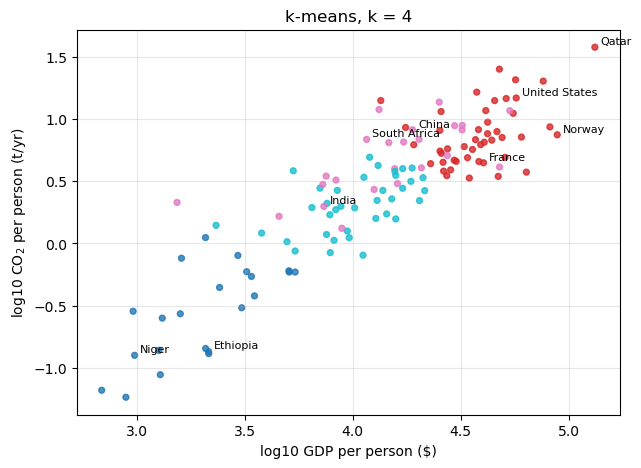

In [5]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=4, n_init=10, random_state=0).fit(X)
c["km"] = km.labels_

fig, ax = plt.subplots(figsize=(7, 5))
scatter(ax, color=c["km"], title="k-means, k = 4")
plt.show()

Always translate the centres back into units you can read. `inverse_transform` undoes the
standardization, and undoing the log gives the geometric mean of each cluster.

In [6]:
centres = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_), columns=feat.columns)
readable = pd.DataFrame({
    "n":            c["km"].value_counts().sort_index(),
    "co2_pc (t)":   10 ** centres["log_co2_pc"],
    "gdp_pc ($)":   10 ** centres["log_gdp_pc"],
    "energy_pc (kWh)": 10 ** centres["log_energy_pc"],
    "coal_share":   centres["coal_share"],
}).round(2)
print(readable)
print()
for k in range(4):
    members = c[c["km"] == k].sort_values("population", ascending=False).index[:6]
    print(f"cluster {k}: {', '.join(members)}")

    n  co2_pc (t)  gdp_pc ($)  energy_pc (kWh)  coal_share
0  22        0.28     2053.71          1172.89        0.18
1  46        7.47    38633.10         48131.95        0.14
2  24        4.76    14736.12         18546.23        0.60
3  37        2.06    10344.56         10539.80        0.10

cluster 0: Nigeria, Bangladesh, Ethiopia, Democratic Republic of Congo, Tanzania, Kenya
cluster 1: United States, Russia, Japan, Iran, Germany, United Kingdom
cluster 2: India, China, Indonesia, Philippines, Vietnam, Turkey
cluster 3: Pakistan, Brazil, Mexico, Egypt, Thailand, Colombia


The algorithm was told nothing about geography or development, and it produced a low-income
group, a middle group, a rich group, and a coal-heavy group cutting across income. That is a
real structure in the data. It is also a structure the choice of features built in: with
`coal_share` removed there would be no coal cluster, because nothing would tell the algorithm
about fuel mix.

## 3. How many clusters?

$k$ is an input, not an output. Two standard diagnostics, neither of which is decisive.

**Inertia** is the total squared distance from each point to its centre. It always falls as
$k$ grows, so you look for the "elbow" where it stops falling quickly. **Silhouette** compares
each point's distance to its own cluster with its distance to the nearest other cluster. Values
near 1 mean tight, separated clusters, and values near 0 mean the clusters overlap.

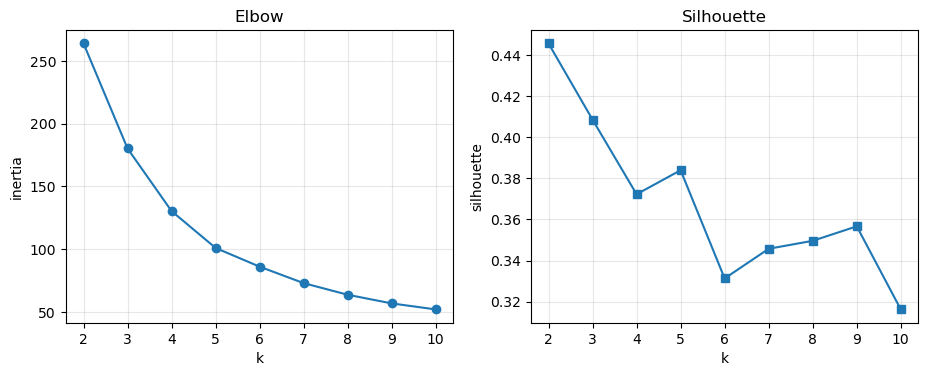

k= 2  inertia= 263.9  silhouette=0.446
k= 3  inertia= 180.2  silhouette=0.409
k= 4  inertia= 130.3  silhouette=0.372
k= 5  inertia= 100.9  silhouette=0.384
k= 6  inertia=  86.0  silhouette=0.331
k= 7  inertia=  72.9  silhouette=0.346
k= 8  inertia=  63.6  silhouette=0.350
k= 9  inertia=  56.7  silhouette=0.357
k=10  inertia=  51.9  silhouette=0.316


In [7]:
from sklearn.metrics import silhouette_score

ks = range(2, 11)
inertia = [KMeans(n_clusters=k, n_init=10, random_state=0).fit(X).inertia_ for k in ks]
sil = [silhouette_score(X, KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(X)) for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(list(ks), inertia, "o-"); axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia"); axes[0].set_title("Elbow")
axes[1].plot(list(ks), sil, "s-"); axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette"); axes[1].set_title("Silhouette")
for ax in axes: ax.grid(alpha=0.3)
plt.show()
for k, i, s in zip(ks, inertia, sil):
    print(f"k={k:2d}  inertia={i:6.1f}  silhouette={s:.3f}")

No sharp elbow, and silhouette values that are modest everywhere. That is the normal outcome
on real data: countries lie along a continuum, not in separate clumps, and any $k$ is a
choice about how finely to slice it. The diagnostics rule out silly values. They do not hand
you the right one. State the choice and the reason for it.

## 4. K-means is not unique

The lecture makes this point and it is worth seeing. K-means starts from random centres and
finds a local optimum. Run it from a single random start several times and compare the
labellings with the **adjusted Rand index**, which is 1 when two partitions agree exactly
and near 0 when they agree no better than chance.

In [8]:
from sklearn.metrics import adjusted_rand_score

runs = [KMeans(n_clusters=4, n_init=1, random_state=seed).fit(X) for seed in range(6)]
print("inertia of each single-start run:", np.round([r.inertia_ for r in runs], 1))
print()
print("adjusted Rand index between run 0 and the others:")
for seed, r in enumerate(runs[1:], 1):
    print(f"  run {seed}: {adjusted_rand_score(runs[0].labels_, r.labels_):.2f}")

inertia of each single-start run: [134.6 148.  131.8 131.2 131.8 131.8]

adjusted Rand index between run 0 and the others:
  run 1: 0.50
  run 2: 0.46
  run 3: 0.63
  run 4: 0.46
  run 5: 0.63


Some runs land in the same place and some do not. This is why scikit-learn's default is
`n_init=10`, ten starts keeping the best. If a result changes when you change the seed, it is
not a finding.

## 5. DBSCAN: density, not centres

DBSCAN has no $k$. A point with at least `min_samples` neighbours within a radius `eps` is a
core point, cores that reach each other form a cluster, and anything not reachable from a core
is labelled $-1$: noise. Two things k-means cannot do follow from that: clusters of any
shape, and an explicit list of outliers.

clusters found: 3 | noise points: 51
noise (51): India, China, Indonesia, Pakistan, Nigeria, Bangladesh, Ethiopia, Philippines ...
cluster 0 (65): Brazil, Russia, Mexico, Japan, Egypt, Iran, Turkey, Germany ...
cluster 1 (8): Poland, Taiwan, Kazakhstan, Czechia, Bulgaria, Serbia, Estonia, Montenegro
cluster 2 (5): United States, Canada, Saudi Arabia, Oman, Kuwait


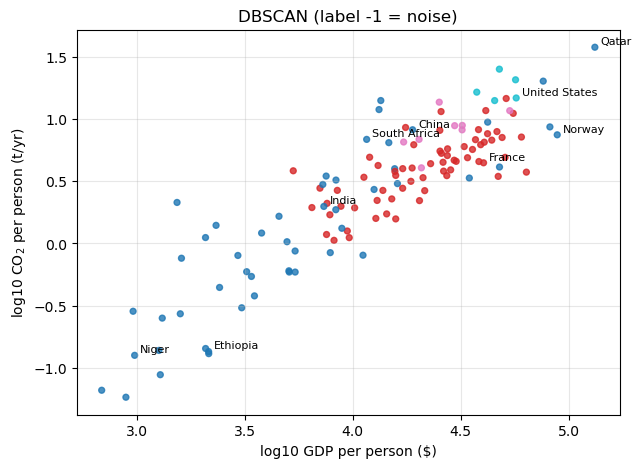

In [9]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.6, min_samples=6).fit(X)
c["db"] = db.labels_
n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
print("clusters found:", n_clusters, "| noise points:", (db.labels_ == -1).sum())
for k in sorted(set(db.labels_)):
    members = c[c["db"] == k].sort_values("population", ascending=False).index
    label = "noise" if k == -1 else f"cluster {k}"
    print(f"{label} ({len(members)}): {', '.join(members[:8])}{' ...' if len(members) > 8 else ''}")

fig, ax = plt.subplots(figsize=(7, 5))
scatter(ax, color=c["db"], title="DBSCAN (label -1 = noise)")
plt.show()

DBSCAN sees the data differently from k-means. It finds two small dense groups that k-means
had folded into larger clusters: the coal economies of eastern Europe and central Asia, and
the very high emitters, the United States, Canada, and the Gulf states. Everything else that
is dense enough forms one mainstream cluster. And then there are the noise points: over a
third of the countries, most of them lower-income. That is not a mistake. Low-income countries
are spread thinly across this feature space, with every combination of fuel mix and income,
so no region among them is dense enough to be called a cluster. K-means had to put them
somewhere. DBSCAN is allowed to say they do not form a group.

In an environmental dataset the same mechanism flags a broken sensor or an unusual event,
which is where Assignment 10 picks the idea up.

`eps` is doing all the work. Change it and the picture changes: too small and everything is
noise, too large and everything is one cluster. There is no free lunch, only a different knob.

In [10]:
for eps in [0.4, 0.5, 0.6, 0.8, 1.0, 1.4]:
    lab = DBSCAN(eps=eps, min_samples=6).fit_predict(X)
    n = len(set(lab)) - (1 if -1 in lab else 0)
    print(f"eps={eps:.1f}: {n} clusters, {(lab == -1).sum():3d} noise points")

eps=0.4: 2 clusters,  94 noise points
eps=0.5: 1 clusters,  77 noise points
eps=0.6: 3 clusters,  51 noise points
eps=0.8: 2 clusters,  10 noise points
eps=1.0: 1 clusters,   3 noise points
eps=1.4: 1 clusters,   1 noise points


## 6. Gaussian mixture models: soft membership

K-means gives every country exactly one label. A Gaussian mixture model instead fits $k$
overlapping bell-shaped distributions and gives each country a **probability** of belonging to
each. That is the right answer for a continuum: a country halfway between two groups should
be reported as halfway, not forced to one side.

In [11]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=4, n_init=5, random_state=0).fit(X)
c["gm"] = gm.predict(X)
resp = gm.predict_proba(X)
c["gm_confidence"] = resp.max(axis=1)

print("countries whose best component has probability below 0.6:")
amb = c[c["gm_confidence"] < 0.6].sort_values("gm_confidence")
print(amb[["gm", "gm_confidence"]].round(2).head(12))

countries whose best component has probability below 0.6:
                    gm  gm_confidence
country                              
Brazil               1           0.46
Spain                0           0.52
Cambodia             2           0.52
Slovakia             1           0.53
Croatia              0           0.55
Finland              3           0.57
Dominican Republic   3           0.57


Those are the countries a hard clustering silently mis-describes. Because a mixture model is a
probability model, it also gives a principled way to compare values of $k$: the **Bayesian
information criterion** penalizes the fit by the number of parameters, and lower is better.

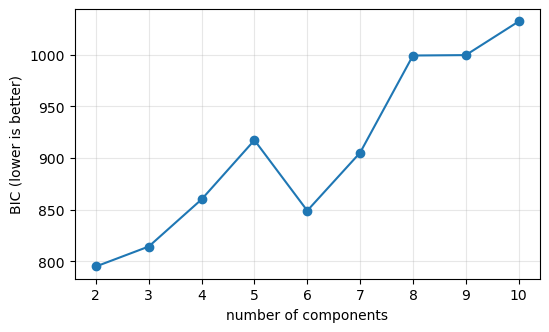

BIC prefers k = 2


In [12]:
bics = [GaussianMixture(n_components=k, n_init=5, random_state=0).fit(X).bic(X) for k in ks]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(list(ks), bics, "o-")
ax.set_xlabel("number of components")
ax.set_ylabel("BIC (lower is better)")
ax.grid(alpha=0.3)
plt.show()
print("BIC prefers k =", list(ks)[int(np.argmin(bics))])

## 7. What the three methods agree on

Put the labellings side by side. Agreement between methods that make different assumptions is
weak evidence that a group is real. A group that only one method finds is probably an artefact
of that method's assumptions.

In [13]:
print(f"ARI, k-means vs GMM:    {adjusted_rand_score(c['km'], c['gm']):.2f}")
print(f"ARI, k-means vs DBSCAN: {adjusted_rand_score(c['km'], c['db']):.2f}")
print()
print(pd.crosstab(c["km"], c["gm"], rownames=["k-means"], colnames=["GMM"]))

ARI, k-means vs GMM:    0.31
ARI, k-means vs DBSCAN: 0.27

GMM       0   1   2   3
k-means                
0         1   0  14   7
1        17  24   0   5
2         0   0   0  24
3        24   3   1   9


## Where this goes next

Three lessons to carry into Assignment 7, where the objects are grid cells described by twelve
months of temperature and twelve of precipitation rather than countries described by four
numbers. First, the features and their scaling decide what "similar" means, before any
algorithm runs. Second, $k$ is a choice you have to defend, not a number the data hands you.
Third, a clustering is a description, not a discovery: check it against something the
algorithm never saw, which for climate zones is the map, and for these countries is what you
already know about them.